<a href="https://colab.research.google.com/github/mohammedislam1776/ml-zoomcamp/blob/main/DTC_ML_ZoomCamp_HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTC ML Zoom Camp Assignment 2

## Load Data


In [524]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-22 01:48:40--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.12’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.04s   

2026-09-22 01:48:40 (14.0 MB/s) - ‘car_fuel_efficiency_2026.csv.12’ saved [635180/635180]



Preparing the dataset
Use only the following columns:

`'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'`





## Question 1: There's one column with missing values. What is it?



In [525]:
import numpy as np
import pandas as pd

In [526]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [527]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [528]:
df = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [529]:
df.isnull().sum()

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


### The column with null values is `'horsepower'`.





## Q1.5 EDA

In [530]:
df.fuel_efficiency_mpg.tail()

,fuel_efficiency_mpg
9995,27.4
9996,30.0
9997,28.1
9998,32.2
9999,30.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

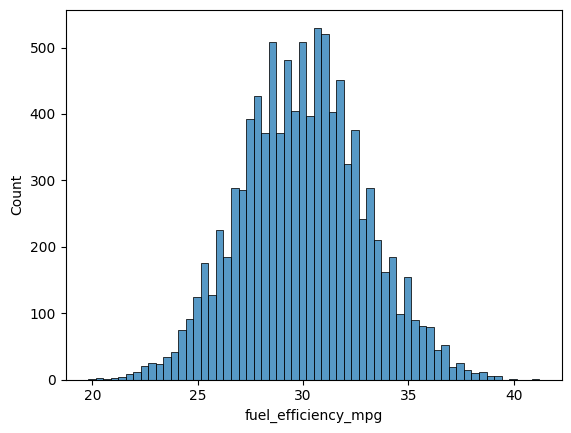

In [531]:
import seaborn as sns
sns.histplot(df['fuel_efficiency_mpg'])

## Question 2: What's the median (50% percentile) for variable 'horsepower'?



In [532]:
df['horsepower'].median()

254.0

## Prepare and split the dataset
Shuffle the filtered dataset and create the split exactly as in the lecture:




**For Q5, repeat the same block with each listed seed. For Q6, use seed 9.**

In [533]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [534]:
#len(df_train), len(df_val), len(df_test)

In [535]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

### Preparing y

In [536]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [537]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Question 3:

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
* Which option gives better RMSE?




In [538]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

base = ['engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year']

def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

### Fill with 0

In [539]:
X_train_zero = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train_zero, y_train)
y_pred_zero = w0 + X_train_zero.dot(w)

In [540]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [541]:
# Evaluate the zero-fill model on the validation dataset
X_val_zero = df_val[base].fillna(0).values
y_pred_zero_val = w0 + X_val_zero.dot(w)
round(rmse(y_val, y_pred_zero_val), 3)

np.float64(2.205)

### Fill with mean

In [542]:
X_train_mean = df_train[base].fillna(df_train[base].mean()).values
w0, w = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w0 + X_train_mean.dot(w)

In [543]:
# Evaluate the mean-fill model on the validation dataset
mean_val = df_train[base]['horsepower'].mean()
X_val_mean = df_val[base].fillna(mean_val).values
y_pred_mean_val = w0 + X_val_mean.dot(w)
round(rmse(y_val, y_pred_mean_val), 3)

np.float64(2.202)

### Filling with the mean is better than filling with 0.





## Q4:
* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0.
* Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
* Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.



In [544]:
df_train_reg = df_train.fillna(0)
df_train_reg.isnull().sum()

,0
engine_displacement,0
horsepower,0
vehicle_weight,0
model_year,0


In [545]:
df_val_reg = df_val.fillna(0)
df_val_reg.isnull().sum()

,0
engine_displacement,0
horsepower,0
vehicle_weight,0
model_year,0


In [546]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

### r = 0

In [547]:
X_train = prepare_X(df_train_reg)
w0, w = train_linear_regression_reg(X_train, y_train, r=0)

X_val = prepare_X(df_val_reg)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),4)

np.float64(2.2053)

### r = 0.01

In [548]:
X_train = prepare_X(df_train_reg)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val_reg)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),4)

np.float64(2.2058)

### r = 0.1

In [549]:
X_train = prepare_X(df_train_reg)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.1)

X_val = prepare_X(df_val_reg)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),4)

np.float64(2.2241)

### r = 1

In [550]:
X_train = prepare_X(df_train_reg)
w0, w = train_linear_regression_reg(X_train, y_train, r=1)

X_val = prepare_X(df_val_reg)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),4)

np.float64(2.3492)

### r = 5

In [551]:
X_train = prepare_X(df_train_reg)
w0, w = train_linear_regression_reg(X_train, y_train, r=5)

X_val = prepare_X(df_val_reg)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),4)

np.float64(2.4094)

### r = 10

In [552]:
X_train = prepare_X(df_train_reg)
w0, w = train_linear_regression_reg(X_train, y_train, r=10)

X_val = prepare_X(df_val_reg)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),4)

np.float64(2.4195)

### Recursive method

In [553]:
for r in [0, 0.000001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]:
    X_train3 = prepare_X(df_train_reg)
    w0_3, w_3 = train_linear_regression_reg(X_train3, y_train, r=r)

    X_val_3 = prepare_X(df_val_reg)
    y_pred_3 = w0_3 + X_val_3.dot(w_3)
    score = rmse(y_val, y_pred_3)

    print(r, round(w0_3,4), round(score,4))

0 -153.885 2.2053
1e-06 -153.8844 2.2053
0.0001 -153.8271 2.2053
0.001 -153.3086 2.2053
0.01 -148.3092 2.2058
0.1 -111.8387 2.2241
1 -32.3319 2.3492
5 -7.7729 2.4094
10 -3.9871 2.4195


## Q5'

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
* Round the result to 3 decimal digits (round(std, 3))

In [554]:
# Calculate training, validation and test split lengths
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

rmse_scores = []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    # Shuffle with different seed
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    # Split dataset cleanly
    df_train_s = df.iloc[idx[:n_train]].copy().reset_index(drop=True)
    df_val_s = df.iloc[idx[n_train:n_train + n_val]].copy().reset_index(drop=True)

    # Target variables on the original scale
    y_train_s = df_train_s.fuel_efficiency_mpg.values
    y_val_s = df_val_s.fuel_efficiency_mpg.values

    # Prepare features and fill missing values with 0
    X_train_s = df_train_s[base].fillna(0).values
    X_val_s = df_val_s[base].fillna(0).values

    # Train linear regression model without regularization
    w0, w = train_linear_regression(X_train_s, y_train_s)

    # Predict directly on the original scale
    y_pred_s = w0 + X_val_s.dot(w)

    # Calculate RMSE
    score = rmse(y_val_s, y_pred_s)
    rmse_scores.append(score)
    print(f'Seed {s}: Validation RMSE = {score:.5f}')

# Compute final standard deviation of the scores
std_dev = np.std(rmse_scores)
print('---')
print('Standard deviation of scores:', std_dev)
print('Rounded standard deviation (3 decimals):', round(std_dev, 3))

Seed 0: Validation RMSE = 2.23920
Seed 1: Validation RMSE = 2.20211
Seed 2: Validation RMSE = 2.16342
Seed 3: Validation RMSE = 2.20436
Seed 4: Validation RMSE = 2.20188
Seed 5: Validation RMSE = 2.24579
Seed 6: Validation RMSE = 2.26972
Seed 7: Validation RMSE = 2.19079
Seed 8: Validation RMSE = 2.21661
Seed 9: Validation RMSE = 2.20704
---
Standard deviation of scores: 0.028781274078191175
Rounded standard deviation (3 decimals): 0.029


## Q6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with r=0.001.
* What's the RMSE on the test dataset?

In [555]:
# Splitting the dataset with seed 9
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

# Splitting into train, validation and test (60%/20%/20%)
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

# Combine train and validation datasets
df_train_val = pd.concat([df_train, df_val]).reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Prepare targets directly on the original scale
y_train_val = df_train_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# Remove target variable from features
del df_train_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# Fill missing values with 0
df_train_val = df_train_val.fillna(0)
df_test = df_test.fillna(0)

# Prepare feature matrices
X_train_val = prepare_X(df_train_val)
X_test = prepare_X(df_test)

# Train model on combined train+val with r=0.001
w0, w = train_linear_regression_reg(X_train_val, y_train_val, r=0.001)

# Predict on the original scale
y_pred = w0 + X_test.dot(w)

# Calculate RMSE on the original target scale
score = rmse(y_test, y_pred)

print('Test RMSE:', score)
print('Rounded Test RMSE (3 decimals):', round(score, 3))

Test RMSE: 2.235827747191731
Rounded Test RMSE (3 decimals): 2.236
